In [17]:
import random
import time
import math
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Алгоритм

In [18]:
def algo(g):
    n = len(g)
    match = [-1] * n

    def dfs(v, used):
        if used[v]:
            return False
        used[v] = True
        for to in g[v]:
            if match[to] == -1 or dfs(match[to], used):
                match[to] = v
                return True
        return False

    for v in range(n):
        used = [False] * n
        dfs(v, used)

    size = sum(1 for x in match if x != -1)
    return size, match

Генерация случайного двудольного графа

In [19]:
def generate_random_graph(n, p=0.5):
    g = []
    for i in range(n):
        edges = []
        for j in range(n):
            if random.random() < p:
                edges.append(j)
        g.append(edges)
    return g

Вспомогательные функции для замера времени

In [20]:
def measure_time_once(n, p=0.3):
    g = generate_random_graph(n, p)

    start = time.perf_counter()
    algo(g)
    end = time.perf_counter()

    return end - start


def measure_series(n_values, repeats=200, p=0.3):
    results = {}

    for n in n_values:
        times = [measure_time_once(n, p) for _ in range(repeats)]
        mean = statistics.mean(times)
        std = statistics.stdev(times) if len(times) > 1 else 0.0

        results[n] = {
            "times": times,
            "mean": mean,
            "std": std
        }

        print(f"n={n:3d}: mean={mean:.8f} sec, std={std:.8f} sec")

    return results

Функции для построения графиков

In [21]:
def plot_mean_std(results):
    n_values = sorted(results.keys())
    means = [results[n]["mean"] for n in n_values]
    stds = [results[n]["std"] for n in n_values]

    lower = [max(0, m - 2*s) for m, s in zip(means, stds)]
    upper = [m + 2*s for m, s in zip(means, stds)]

    plt.figure(figsize=(10, 6))
    plt.plot(n_values, means, marker='o', label='Среднее время')
    plt.fill_between(n_values, lower, upper, alpha=0.3, label='2 ско')
    plt.xlabel('n')
    plt.ylabel('Время (сек)')
    plt.title('Зависимость времени работы алгоритма от n')
    plt.legend()
    plt.grid(True)
    plt.show()



def plot_histogram(times, n):
    plt.figure(figsize=(9, 5))
    plt.hist(times, bins=20, edgecolor='black')
    plt.xlabel('Время (сек)')
    plt.ylabel('Частота')
    plt.title('Гистограмма времени работы для n = ' + str(n))
    plt.grid(True)
    plt.show()

Проверка гипотезы о распределении

In [22]:
def test_distribution(times, distribution='lognormal'):
    arr = np.array(times)

    if distribution == 'normal':
        mu, sigma = stats.norm.fit(arr)
        stat, pvalue = stats.kstest(arr, 'norm', args=(mu, sigma))
        return pvalue

    elif distribution == 'lognormal':
        shape, loc, scale = stats.lognorm.fit(arr, floc=0)
        stat, pvalue = stats.kstest(arr, 'lognorm', args=(shape, loc, scale))
        return pvalue

    else:
        print('Распределение ни логнормальное, ни нормальное')

Итог: полноценное тестирование производительности

In [25]:
def chi2_for_times(times, bins=10, alpha=0.05):
    arr = np.array(times)

    df, loc, scale = stats.chi2.fit(arr)


    observed, edges = np.histogram(arr, bins=bins)
    observed = observed.astype(float)


    expected = []
    for i in range(len(edges) - 1):
        p = stats.chi2.cdf(edges[i + 1], df, loc=loc, scale=scale) - \
            stats.chi2.cdf(edges[i], df, loc=loc, scale=scale)
        expected.append(len(arr) * p)

    expected = np.array(expected)


    expected *= observed.sum() / expected.sum()


    print("Ожидаемые частоты:", expected)


    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    dof = len(observed) - 1 - 3
    p_value = stats.chi2.sf(chi2_stat, dof) if dof > 0 else np.nan

    print("χ² =", chi2_stat)
    print("p-value =", p_value)

    if not np.isnan(p_value) and p_value > alpha:
        print("Принимаем гипотезу о согласии с распределением χ².")
    else:
        print("Не принимаем гипотезу о согласии с распределением χ².")

n= 10: mean=0.00001552 sec, std=0.00006924 sec
n= 20: mean=0.00011407 sec, std=0.00085552 sec
n= 30: mean=0.00006893 sec, std=0.00004546 sec
n= 40: mean=0.00011301 sec, std=0.00003256 sec
n= 50: mean=0.00020700 sec, std=0.00003654 sec
n= 60: mean=0.00035644 sec, std=0.00004649 sec
n= 80: mean=0.00086584 sec, std=0.00006320 sec
n=100: mean=0.00210808 sec, std=0.00026741 sec
n=120: mean=0.00409513 sec, std=0.00041600 sec
n=150: mean=0.00808547 sec, std=0.00058350 sec
n=170: mean=0.01175752 sec, std=0.00060384 sec
n=180: mean=0.01374177 sec, std=0.00063730 sec
n=190: mean=0.01605879 sec, std=0.00063612 sec
n=200: mean=0.01898624 sec, std=0.00069972 sec
n=210: mean=0.02253650 sec, std=0.00074379 sec
n=220: mean=0.02629399 sec, std=0.00126620 sec


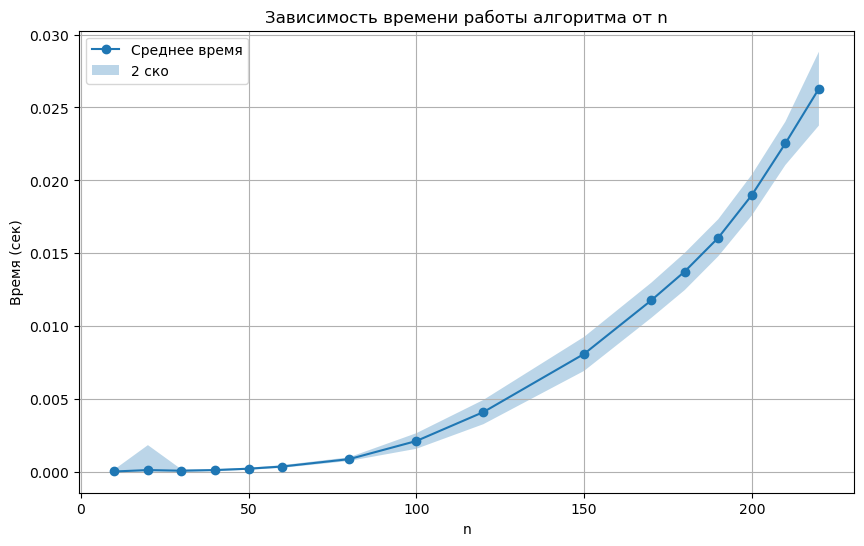

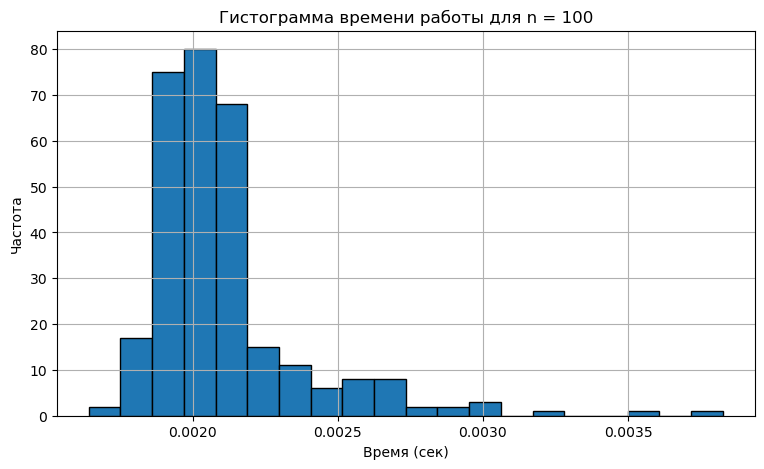


Проверка гипотезы о распределении для n = 100
Нормальное распределение:
4.546413327152401e-10

Логнормальное распределение:
3.4327574329156754e-07

Лучше согласуется распределение: логнормальное
p-value = 3.4327574329156754e-07
Ожидаемые частоты: [220.28573325  21.49010716  13.51920422  10.04289849   8.05802885
   6.76305307   5.8468241    5.16201989   4.62946657   4.20266441]
χ² = 1394.26533812053
p-value = 4.2264476159696675e-298
Не принимаем гипотезу о согласии с распределением χ².


In [26]:
random.seed(42)
np.random.seed(42)

# Набор размеров входа
n_values = [10, 20, 30, 40, 50, 60, 80, 100, 120, 150, 170, 180, 190, 200, 210, 220]
repeats = 300
p = 0.3

results = measure_series(n_values, repeats=repeats, p=p)

# График зависимости времени от n
plot_mean_std(results)


selected_n = 100
times = results[selected_n]["times"]

# Гистограмма
plot_histogram(times, selected_n)

# Проверка гипотезы о распределении
normal_test = test_distribution(times, distribution='normal')
lognormal_test = test_distribution(times, distribution='lognormal')

print("\nПроверка гипотезы о распределении для n =", selected_n)
print("Нормальное распределение:")
print(normal_test)

print("\nЛогнормальное распределение:")
print(lognormal_test)

# Выбор лучшей гипотезы по p-value
if normal_test > lognormal_test:
    best = normal_test
    print("\nЛучше согласуется распределение: нормальное")
    print("p-value =", best)
else:
    best= lognormal_test
    print("\nЛучше согласуется распределение: логнормальное")
    print("p-value =", best)

chi2_for_times(times)